# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShamKottish/FlyRankML/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn

import os
import json
import getpass
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

RANDOM_STATE = 42

# -----------------------------
# Hugging Face authentication
# -----------------------------

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass(
    "Paste your Hugging Face READ token: "
)

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_MAR = (
    f"read_parquet('{REL}/"
    "fact_content_daily_performance/month=2026-03/*.parquet')"
)

FACT_APR = (
    f"read_parquet('{REL}/"
    "fact_content_daily_performance/month=2026-04/*.parquet')"
)

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Connected")
print("Feature window: March 2026")
print("Outcome window: April 2026")

Paste your Hugging Face READ token: ··········
✓ Connected
Feature window: March 2026
Outcome window: April 2026


In [2]:
# ============================================================
# REBUILD FINAL MODELING FRAME
# ============================================================

march = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS feature_impressions,
        SUM(gsc_clicks) AS feature_clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks)
                 / SUM(gsc_impressions)
        END AS feature_ctr,

        SUM(
            CASE
                WHEN gsc_avg_position > 0
                     AND gsc_impressions > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        )
        /
        NULLIF(
            SUM(
                CASE
                    WHEN gsc_avg_position > 0
                         AND gsc_impressions > 0
                    THEN gsc_impressions
                    ELSE 0
                END
            ),
            0
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN gsc_avg_position > 0
                     AND gsc_impressions > 0
                THEN gsc_avg_position
            END
        ) AS feature_position_std,

        COUNT(
            DISTINCT CASE
                WHEN gsc_impressions > 0
                THEN report_date
            END
        ) AS feature_active_days

    FROM {FACT_MAR}

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 500
""").df()

march["feature_position_std"] = (
    march["feature_position_std"].fillna(0)
)

march = march[
    march["feature_avg_position"].notna()
].copy()


# -----------------------------
# April outcome
# -----------------------------

april = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS outcome_impressions,
        SUM(gsc_clicks) AS outcome_clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks)
                 / SUM(gsc_impressions)
        END AS outcome_ctr,

        SUM(
            CASE
                WHEN gsc_avg_position > 0
                     AND gsc_impressions > 0
                THEN gsc_avg_position * gsc_impressions
                ELSE 0
            END
        )
        /
        NULLIF(
            SUM(
                CASE
                    WHEN gsc_avg_position > 0
                         AND gsc_impressions > 0
                    THEN gsc_impressions
                    ELSE 0
                END
            ),
            0
        ) AS outcome_avg_position

    FROM {FACT_APR}

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 500
""").df()

april = april[
    april["outcome_avg_position"].notna()
].copy()


def position_band(position):
    if position <= 3:
        return "top_3"
    elif position <= 10:
        return "page_1"
    elif position <= 20:
        return "striking"
    elif position <= 50:
        return "page_3_5"
    return "deep"


april["outcome_position_band"] = (
    april["outcome_avg_position"]
    .apply(position_band)
)

april["outcome_band_median_ctr"] = (
    april
    .groupby("outcome_position_band")["outcome_ctr"]
    .transform("median")
)

april["outcome_ctr_gap_pp"] = (
    april["outcome_band_median_ctr"]
    - april["outcome_ctr"]
)

april["opportunity_proxy"] = (
    april["outcome_ctr_gap_pp"] > 0.10
).astype(int)


# -----------------------------
# Join feature and outcome data
# -----------------------------

model_df = march.merge(
    april[
        [
            "client_hash_id",
            "content_hash_id",
            "outcome_ctr_gap_pp",
            "opportunity_proxy",
        ]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df["log_impressions"] = np.log1p(
    model_df["feature_impressions"]
)

model_df["log_clicks"] = np.log1p(
    model_df["feature_clicks"]
)

FEATURES = [
    "log_impressions",
    "log_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_position_std",
    "feature_active_days",
]

TARGET = "opportunity_proxy"


# ============================================================
# HONEST CLIENT HOLDOUT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        model_df,
        model_df[TARGET],
        groups=model_df["client_hash_id"]
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

assert set(train_df["client_hash_id"]).isdisjoint(
    set(test_df["client_hash_id"])
)


# ============================================================
# MODEL
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(
    train_df[FEATURES],
    train_df[TARGET]
)

test_df["model_score"] = rf.predict_proba(
    test_df[FEATURES]
)[:, 1]


def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))
    order = np.argsort(-scores)

    return y_true[order[:k]].mean()


VALIDATED_P50 = precision_at_k(
    test_df[TARGET],
    test_df["model_score"],
    50
)

VALIDATED_BASE_RATE = test_df[TARGET].mean()

print(f"Held-out rows: {len(test_df):,}")
print(f"Base rate: {VALIDATED_BASE_RATE:.3f}")
print(f"Validated Precision@50: {VALIDATED_P50:.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Held-out rows: 26,012
Base rate: 0.215
Validated Precision@50: 0.880


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


The playbook converts the model score into a **human-review queue**, not an automatic editing queue.

Items are ranked from highest to lowest model score. Each recommendation also receives transparent reason codes based only on March measurements so that a reviewer can understand why the page reached the top of the queue.

The main actions are:

- `review_title_meta_and_intent` — inspect the title, meta description, SERP presentation, and whether the page matches likely search intent.
- `review_snippet_and_query_fit` — inspect how the page is presented in search before changing the page itself.
- `monitor_position_before_edit` — ranking position was unstable, so wait or investigate before attributing the problem to content.
- `manual_review_only` — the model score is elevated but the transparent signals are not strong enough to justify a specific edit.

Reason codes include high search visibility, low CTR relative to comparable March positions, strong search position with a CTR gap, and high position volatility.

These are decision-support recommendations. They identify pages that look worth reviewing first; they do not establish that an edit will improve CTR.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# TRAIN-ONLY CTR REFERENCES
# ============================================================

train_df["feature_position_band"] = (
    train_df["feature_avg_position"]
    .apply(position_band)
)

test_df["feature_position_band"] = (
    test_df["feature_avg_position"]
    .apply(position_band)
)

train_band_ctr = (
    train_df
    .groupby("feature_position_band")["feature_ctr"]
    .median()
    .to_dict()
)

fallback_ctr = train_df["feature_ctr"].median()

test_df["peer_median_ctr"] = (
    test_df["feature_position_band"]
    .map(train_band_ctr)
    .fillna(fallback_ctr)
)

test_df["march_ctr_gap_pp"] = (
    test_df["peer_median_ctr"]
    - test_df["feature_ctr"]
)


# ============================================================
# REASON CODES
# ============================================================

def reason_codes(row):
    reasons = []

    if row["feature_impressions"] >= 3000:
        reasons.append("high_visibility")

    if row["march_ctr_gap_pp"] >= 0.10:
        reasons.append("below_position_peer_ctr")

    if (
        row["feature_avg_position"] <= 20
        and row["march_ctr_gap_pp"] >= 0.10
    ):
        reasons.append("strong_position_ctr_gap")

    if row["feature_position_std"] >= 10:
        reasons.append("position_volatile")

    if not reasons:
        reasons.append("model_priority_only")

    return "; ".join(reasons)


def choose_action(row):
    if row["feature_position_std"] >= 10:
        return "monitor_position_before_edit"

    if (
        row["feature_avg_position"] <= 20
        and row["march_ctr_gap_pp"] >= 0.10
    ):
        return "review_title_meta_and_intent"

    if row["march_ctr_gap_pp"] >= 0.10:
        return "review_snippet_and_query_fit"

    return "manual_review_only"


def confidence_note(row):
    if (
        row["model_score"] >= 0.75
        and row["feature_impressions"] >= 3000
        and row["march_ctr_gap_pp"] >= 0.10
        and row["feature_position_std"] < 10
    ):
        return "higher"

    if row["model_score"] >= 0.50:
        return "moderate"

    return "lower"


test_df["reason_codes"] = test_df.apply(
    reason_codes,
    axis=1
)

test_df["recommended_action"] = test_df.apply(
    choose_action,
    axis=1
)

test_df["confidence_note"] = test_df.apply(
    confidence_note,
    axis=1
)


# Ranked demonstration queue
action_queue = (
    test_df
    .sort_values(
        "model_score",
        ascending=False
    )
    .reset_index(drop=True)
)

action_queue.insert(
    0,
    "rank",
    np.arange(1, len(action_queue) + 1)
)

PUBLIC_QUEUE_COLUMNS = [
    "rank",
    "content_hash_id",
    "model_score",
    "recommended_action",
    "reason_codes",
    "confidence_note",
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "march_ctr_gap_pp",
    "feature_position_std",
]

playbook_queue = action_queue[
    PUBLIC_QUEUE_COLUMNS
].copy()

print(f"Ranked queue rows: {len(playbook_queue):,}")

display(
    playbook_queue.head(20)
)

Ranked queue rows: 26,012


,rank,content_hash_id,model_score,recommended_action,reason_codes,confidence_note,feature_impressions,feature_ctr,feature_avg_position,march_ctr_gap_pp,feature_position_std
0,1,content_96bcbfd602ef158e,0.914053,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,15107.0,0.006619,6.456477,0.251879,0.871045
1,2,content_92d2c3fc8bf462c9,0.910098,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,8343.0,0.000000,6.171401,0.258498,0.898454
2,3,content_4257d1459eb1fdd1,0.909156,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,20741.0,0.019285,6.671134,0.239213,0.654290
3,4,content_bcc0248af1702d97,0.908570,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,13369.0,0.022440,5.718827,0.236058,0.820202
4,5,content_244cb9de873cae3e,0.907557,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,8875.0,0.022535,6.779155,0.235963,0.649198
5,6,content_5b428f5c6e80ff0b,0.907552,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,12283.0,0.008141,6.476756,0.250357,1.291340
6,7,content_2302b2db40b8188d,0.907174,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,9604.0,0.020825,7.535090,0.237673,0.613184
7,8,content_3a9aa0258f31b923,0.907054,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,11978.0,0.041743,5.037986,0.216755,0.693853
8,9,content_345c8feeab5d080a,0.906755,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,23418.0,0.004270,4.969980,0.254228,0.558945
9,10,content_e7f0b8bdc0ace93a,0.906400,review_title_meta_and_intent,high_visibility; below_position_peer_ctr; stro...,higher,7423.0,0.013472,5.033814,0.245026,0.520890


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


This playbook is intended for an SEO specialist, content editor, or content operations team that has limited review capacity and needs help deciding **which pages to inspect first**.

The score is useful for prioritization, not automatic publishing. A high-ranked item means that its observed March search signals resemble pages associated with the later CTR-opportunity proxy in the historical data.

The current validation covers pages with at least 500 impressions and measurable search position. The reported model result comes from clients held completely out of training, which makes it more credible than a random page split, but it does not guarantee the same performance for every future client or time period.

The current queue is a historical held-out demonstration queue. A live deployment would rerun the same feature logic on a current feature window and should be monitored for drift before recommendations are acted on at scale.

The model does not know why CTR is weak. SERP layout, brand recognition, query intent, ranking changes, seasonality, or competitor changes can all affect the observed pattern. It therefore cannot prove that rewriting a title, meta description, or page will improve performance.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Verify the intended-use boundaries numerically.

use_limits = pd.DataFrame([
    {
        "item": "minimum feature impressions",
        "value": 500,
        "meaning": "reduces very low-volume CTR noise"
    },
    {
        "item": "held-out clients",
        "value": test_df["client_hash_id"].nunique(),
        "meaning": "clients not seen during model training"
    },
    {
        "item": "held-out rows",
        "value": len(test_df),
        "meaning": "historical evaluation population"
    },
    {
        "item": "validated Precision@50",
        "value": round(float(VALIDATED_P50), 3),
        "meaning": "top-50 performance on held-out clients"
    },
    {
        "item": "held-out base rate",
        "value": round(float(VALIDATED_BASE_RATE), 3),
        "meaning": "comparison rate without ranking"
    },
])

display(use_limits)

# Make sure future outcome fields did not enter the public queue.
forbidden_public_columns = [
    c for c in playbook_queue.columns
    if "outcome" in c.lower()
    or "april" in c.lower()
    or "proxy" in c.lower()
]

assert forbidden_public_columns == []

print("✓ Public action queue contains no outcome/label fields.")

,item,value,meaning
0,minimum feature impressions,500.000,reduces very low-volume CTR noise
1,held-out clients,9.000,clients not seen during model training
2,held-out rows,26012.000,historical evaluation population
3,validated Precision@50,0.880,top-50 performance on held-out clients
4,held-out base rate,0.215,comparison rate without ranking


✓ Public action queue contains no outcome/label fields.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


Before acting on a recommendation, a human reviewer must check:

1. whether the current page is still live and relevant;
2. whether its ranking position has recently changed;
3. whether the search intent actually matches the page;
4. whether the title and description accurately describe the content;
5. whether seasonality, SERP features, or brand effects could explain the CTR pattern;
6. whether the page is strategically important enough to justify an edit;
7. whether a proposed change could harm a page that is already performing well for another query or audience.

### No-go list

The system should **never automatically**:

- rewrite or publish titles or content;
- delete, redirect, or deindex pages;
- change canonical tags or other technical SEO settings;
- infer private customer or client information;
- treat a model score as proof of poor content quality;
- claim that Google rewards or penalizes a specific feature;
- promise that an edit will increase rankings, clicks, or traffic.

Every recommendation requires human judgment before implementation.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
human_review_checklist = [
    "Confirm the page is still live and relevant",
    "Check recent ranking movement",
    "Check search-intent match",
    "Review title and SERP presentation",
    "Check seasonality and SERP changes",
    "Assess business/content importance",
    "Consider downside of changing an already useful page",
]

no_go_actions = [
    "automatic_publish",
    "automatic_title_rewrite",
    "automatic_page_delete",
    "automatic_redirect",
    "automatic_deindex",
    "automatic_canonical_change",
    "causal_claim_from_model_score",
]

review_policy = pd.DataFrame({
    "human_review_required": human_review_checklist
})

no_go_policy = pd.DataFrame({
    "never_automate": no_go_actions
})

print("Human-review checklist:")
display(review_policy)

print("\nNo-go list:")
display(no_go_policy)

assert len(human_review_checklist) >= 5
assert len(no_go_actions) >= 5

print("✓ Human review and no-go policy documented.")

Human-review checklist:


,human_review_required
0,Confirm the page is still live and relevant
1,Check recent ranking movement
2,Check search-intent match
3,Review title and SERP presentation
4,Check seasonality and SERP changes
5,Assess business/content importance
6,Consider downside of changing an already usefu...



No-go list:


,never_automate
0,automatic_publish
1,automatic_title_rewrite
2,automatic_page_delete
3,automatic_redirect
4,automatic_deindex
5,automatic_canonical_change
6,causal_claim_from_model_score


✓ Human review and no-go policy documented.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*


The recommendations should be treated as stale if their measured usefulness or input population changes materially.

I would trigger investigation or retraining when any of the following occurs:

- **Precision@50 falls by more than 0.10 absolute** from the validated held-out result on a later labeled window.
- Precision@50 falls close to the new population's base rate, meaning the ranking provides little practical lift.
- More than **20% of new observations** fall outside the 1st–99th percentile range of a major training feature, suggesting input drift.
- Missingness in an important feature increases by more than **5 percentage points** from the training reference.
- The data schema, search measurement definitions, or feature-generation logic changes.
- A substantial new client population or content type appears that was not represented during validation.

Retraining should not happen merely because a calendar date passed. It should happen when measured performance, feature distributions, or the operational environment indicate that the learned relationships may no longer hold.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Store transparent monitoring thresholds.

monitoring_rules = pd.DataFrame([
    {
        "trigger": "precision_at_50_drop",
        "threshold": 0.10,
        "action": "investigate and retrain if confirmed"
    },
    {
        "trigger": "precision_close_to_base_rate",
        "threshold": 0.05,
        "action": (
            "investigate if Precision@50 is less than "
            "5 percentage points above base rate"
        )
    },
    {
        "trigger": "feature_out_of_range_share",
        "threshold": 0.20,
        "action": "inspect feature drift"
    },
    {
        "trigger": "missingness_increase",
        "threshold": 0.05,
        "action": "inspect data pipeline and retrain if needed"
    },
])

display(monitoring_rules)


# Training reference ranges for later drift monitoring.
reference_features = [
    "log_impressions",
    "log_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_position_std",
    "feature_active_days",
]

drift_reference = pd.DataFrame({
    "feature": reference_features,
    "p01": [
        train_df[c].quantile(0.01)
        for c in reference_features
    ],
    "median": [
        train_df[c].median()
        for c in reference_features
    ],
    "p99": [
        train_df[c].quantile(0.99)
        for c in reference_features
    ],
    "missing_rate": [
        train_df[c].isna().mean()
        for c in reference_features
    ],
})

display(drift_reference.round(3))

print(
    f"Validated Precision@50 reference: "
    f"{VALIDATED_P50:.3f}"
)

print(
    f"Validated base-rate reference: "
    f"{VALIDATED_BASE_RATE:.3f}"
)

,trigger,threshold,action
0,precision_at_50_drop,0.10,investigate and retrain if confirmed
1,precision_close_to_base_rate,0.05,investigate if Precision@50 is less than 5 per...
2,feature_out_of_range_share,0.20,inspect feature drift
3,missingness_increase,0.05,inspect data pipeline and retrain if needed


,feature,p01,median,p99,missing_rate
0,log_impressions,6.271,7.739,10.539,0.0
1,log_clicks,0.000,1.792,5.004,0.0
2,feature_ctr,0.000,0.221,1.821,0.0
3,feature_avg_position,1.099,6.206,48.296,0.0
4,feature_position_std,0.428,2.666,17.370,0.0
5,feature_active_days,10.000,31.000,31.000,0.0


Validated Precision@50 reference: 0.880
Validated base-rate reference: 0.215


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*


I export three reproducible artifacts:

1. `work/outputs/action_playbook_queue.csv` — the ranked historical demonstration queue.
2. `work/outputs/action_playbook_metrics.json` — compact validation and monitoring numbers used by the paper.
3. `work/figures/action_playbook_top20.png` — a figure showing the model scores of the first 20 recommendations.

The CSV contains only pseudonymized content IDs and safe observed/derived fields. It contains no client names, domains, URLs, titles, raw queries, or April labels.

The metrics JSON is the main committed receipt for the paper's numerical claims.

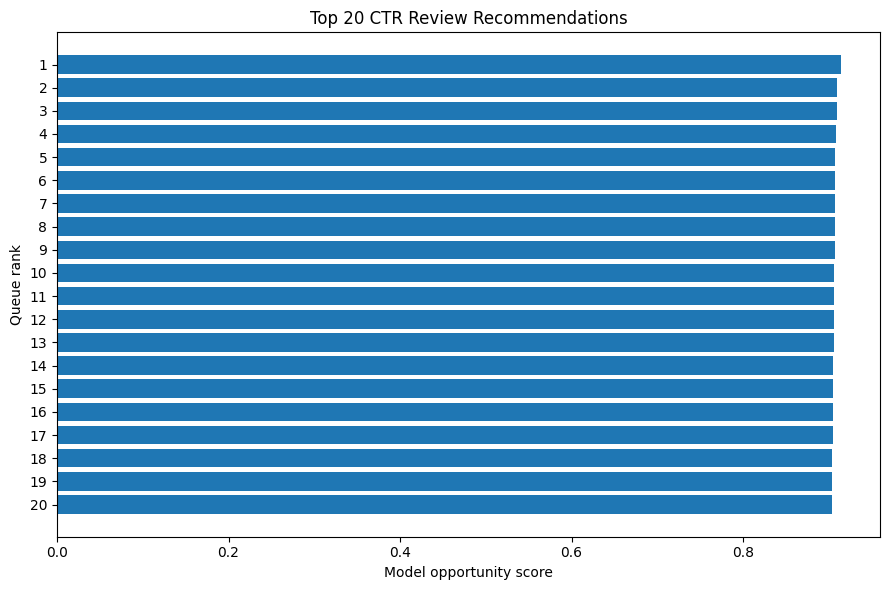

✓ Queue: work/outputs/action_playbook_queue.csv
✓ Metrics receipt: work/outputs/action_playbook_metrics.json
✓ Figure: work/figures/action_playbook_top20.png

Paper metrics:
{
  "lane": "CTR opportunity scoring",
  "feature_window": "2026-03-01 to 2026-03-31",
  "outcome_window": "2026-04-01 to 2026-04-30",
  "validation": "grouped client holdout",
  "random_state": 42,
  "heldout_rows": 26012,
  "heldout_clients": 9,
  "base_rate": 0.21524680916500077,
  "precision_at_50": 0.88,
  "queue_rows": 26012,
  "minimum_impressions": 500,
  "claim_level": "observational decision-support"
}


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ============================================================
# 1. WRITE THE QUEUE
# ============================================================

QUEUE_PATH = (
    OUTPUT_DIR
    / "action_playbook_queue.csv"
)

playbook_queue.to_csv(
    QUEUE_PATH,
    index=False
)


# ============================================================
# 2. WRITE COMPACT METRICS RECEIPT
# ============================================================

METRICS_PATH = (
    OUTPUT_DIR
    / "action_playbook_metrics.json"
)

metrics_receipt = {
    "lane": "CTR opportunity scoring",
    "feature_window": "2026-03-01 to 2026-03-31",
    "outcome_window": "2026-04-01 to 2026-04-30",
    "validation": "grouped client holdout",
    "random_state": RANDOM_STATE,
    "heldout_rows": int(len(test_df)),
    "heldout_clients": int(
        test_df["client_hash_id"].nunique()
    ),
    "base_rate": float(VALIDATED_BASE_RATE),
    "precision_at_50": float(VALIDATED_P50),
    "queue_rows": int(len(playbook_queue)),
    "minimum_impressions": 500,
    "claim_level": "observational decision-support",
}

with open(METRICS_PATH, "w") as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )


# ============================================================
# 3. PAPER FIGURE
# ============================================================

top20 = playbook_queue.head(20).copy()

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top20["rank"].astype(str),
    top20["model_score"]
)

ax.invert_yaxis()

ax.set_xlabel("Model opportunity score")
ax.set_ylabel("Queue rank")
ax.set_title(
    "Top 20 CTR Review Recommendations"
)

fig.tight_layout()

FIGURE_PATH = (
    FIGURE_DIR
    / "action_playbook_top20.png"
)

fig.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# VERIFY
# ============================================================

assert QUEUE_PATH.exists()
assert METRICS_PATH.exists()
assert FIGURE_PATH.exists()

print("✓ Queue:", QUEUE_PATH)
print("✓ Metrics receipt:", METRICS_PATH)
print("✓ Figure:", FIGURE_PATH)

print("\nPaper metrics:")
print(json.dumps(metrics_receipt, indent=2))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.